<a href="https://colab.research.google.com/github/stephen-matthews/CECS-101-Digital-Portfolio/blob/main/Stephen_Matthews_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

This cell imports 4 libraries, but does nothing to the data. With aliases I only have to type the abbrevation instead of full word.
numpy provides numerical operations on arrays.
pandas provides the Dataframe which holds the dataset in a table with labeled rows and columns.
matplotlib.pyplot provides chart creation.
seaborn provides statistical visualizations to work on top of matplotlib.pyplot for better defaults.

In [ ]:
finance_df = pd.read_csv('/content/drive/MyDrive/finance_data.csv')
display(finance_df.head())

,year,quarter,company_id,sector,revenue,profit_margin,profit,stock_price,pe_ratio,debt_to_equity,dividend_yield,market_cap
0,2000,1,Company_1,Finance,2.198686e+08,0.04,9755484.56,36.15,3.71,1.42,0.01,2.363830e+09
1,2000,1,Company_2,Consumer Goods,3.298028e+08,0.06,18814148.79,54.22,2.88,1.71,0.01,3.956767e+09
2,2000,1,Company_3,Finance,4.397371e+08,0.07,30660094.32,72.29,2.36,1.66,0.03,3.633502e+09
3,2000,1,Company_4,Energy,5.496714e+08,0.08,45293321.16,90.37,2.00,1.07,0.05,3.833839e+09
4,2000,1,Company_5,Manufacturing,6.596057e+08,0.10,62713829.30,108.44,1.73,1.36,0.02,6.178690e+09


This cell is a sanity check. finance_df = stores the result in a variable (finance_df) and refers to the data by that name. pd.read_csv('/content/finance_data.csv') reads the CSV file and turns it into a DataFrame. /content is the folder Colab uses as the working directory.

display shows the DataFrame as an HTML table, otherwise it would be done in plain text with print. .head() returns the first 5 rows of the DataFrame by default to prevent flooding the screen.

The output shows 12 columns and 5 rows showing quarterly finacial figures for companies by sector in 2000. The column names came from the header row of the CSV file, while pandas added the index numbers 0 through 4 on the left. Pandas also converted the large numbers to scientific notation to keep the columns readable.


In [ ]:
# This code displays the number of rows, columns, and cells in the dataset.
size = finance_df.size

shape = finance_df.shape

print("Size = {}\nShape = {}".format(size, shape))
print('Rows: ', finance_df.shape[0])
print('Cols: ', finance_df.shape[1])

Size = 30000
Shape = (2500, 12)
Rows:  2500
Cols:  12


.# This code displays... is a comment or note for the code. It doesn't get used when the cell runs.

.size is a DataFrame property that gives the total number of cells in the table as a single number. .shape gives both dimensions as a pair, with rows first and columns second. That pair is called a tuple.

"Size = {}\nShape = {}".format(size, shape) is string formatting. The {} are placeholders. .format() fills the first one with size and the second with shape. The \n means start a new line, so the values print on separate lines.

finance_df.shape[0] and [1] pull one piece out of that pair. Python counts from 0, so 0 is the rows and 1 is the columns.

The output shows Size = 30000, Shape = (2500, 12), Rows: 2500, and Cols: 12. This means the dataset has 2,500 rows and 12 columns, and 2,500 × 12 = 30,000 total cells, which is where the size number comes from. Running this early tells me how much data I'm working with before I analyze it

In [ ]:
# Basic statistics
print("\nBasic Statistics:")
print(finance_df.describe())


Basic Statistics:
              year      quarter       revenue  profit_margin        profit  \
count  2500.000000  2500.000000  2.500000e+03    2500.000000  2.500000e+03   
mean   2012.000000     2.500000  2.658120e+09       0.373936  1.199423e+09   
std       7.212545     1.118258  1.624470e+09       0.221228  1.129004e+09   
min    2000.000000     1.000000  1.727128e+08       0.030000  7.817187e+06   
25%    2006.000000     1.750000  1.329516e+09       0.200000  2.821963e+08   
50%    2012.000000     2.500000  2.409744e+09       0.340000  8.637113e+08   
75%    2018.000000     3.250000  3.729541e+09       0.510000  1.803392e+09   
max    2024.000000     4.000000  8.114111e+09       1.330000  6.382023e+09   

       stock_price     pe_ratio  debt_to_equity  dividend_yield    market_cap  
count  2500.000000  2500.000000     2379.000000     2500.000000  2.500000e+03  
mean    465.459628     0.741324        1.193817        0.020316  2.526694e+10  
std     283.374544     0.632146       

The print("\nBasic Statistics:") prints label and  the \n adds a blank line.The .describe() generates a statistical summary of every numeric column.

Giving you count (non-missing values in a column), mean (the average), standard deviation (how dispersed the values are), min (smallest value), 25% (the first quartile), 50% (the median), 75% (third quartile), max (largest value).

The debt_to_equity column shows a count of 2379 instead of 2500, which means 121 values are missing from that column.

Only 10 of the 12 columns appear in the output. The company_id and sector columns are left out because they contain text, and .describe() only works on numeric columns.

In [ ]:
# Counts of missing values
print("\nMissing Values Count:")
print(finance_df.isnull().sum())


Missing Values Count:
year                0
quarter             0
company_id          0
sector              0
revenue             0
profit_margin       0
profit              0
stock_price         0
pe_ratio            0
debt_to_equity    121
dividend_yield      0
market_cap          0
dtype: int64


This cell confirms the previous information. The .isnull() goes through every cell in the table and checks for empty cells, coming back with True or False. The .sum() adds those values up, True being 1 and False being 0. Chaining them together as finance_df.isnull().sum() runs the first and then gives the result to the second.

The output is one line per column showing how many values are missing in each. The dtype: int64 at the bottom tells me the counts are whole numbers. Eleven columns are complete and debt_to_equity is missing 121 values. That lines up with the previous cell, since 2500 total rows minus 121 missing gives the 2379 that .describe() reported.

The difference is that .describe() only hinted at the problem, and only for the numeric columns. This cell checks all 12 directly and states it plainly. I would run it before deciding whether to drop those 121 rows or fill them in.

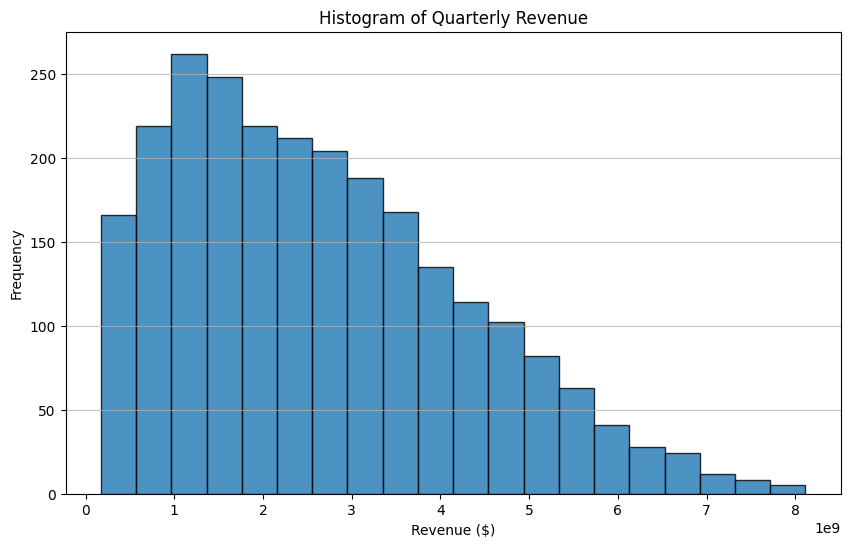

In [ ]:
# Histogram of revenue data
plt.figure(figsize=(10, 6))
plt.hist(finance_df['revenue'], bins=20, edgecolor='black', alpha=0.8)
plt.title('Histogram of Quarterly Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))  # Use scientific notation for large numbers
plt.savefig('revenue_histogram.png')
plt.show()

plt.figure(figsize=(10, 6)) creates a blank chart set to 10 inches wide by 6 inches tall.

plt.hist(finance_df['revenue'], bins=20, edgecolor='black', alpha=0.8) is the main line. finance_df['revenue'] grabs the revenue column using square brackets. .hist builds a histogram, which sorts the values into ranges and counts how many fall into each one. bins=20 splits the range into 20 bars. edgecolor='black' outlines each bar in black. alpha=0.8 makes the bars slightly see through.

plt.title, plt.xlabel, and plt.ylabel set the text for the top, bottom, and left side. plt.grid(axis='y', alpha=0.75) adds faint horizontal lines to read heights better. plt.ticklabel_format(...) forces scientific notation on the x-axis, which is the 1e9 in the bottom right corner indicating the numbers are in billions. plt.savefig('revenue_histogram.png') saves the chart as an image in the file panel. plt.show() displays it.

In the output, the x-axis is revenue in billions and the y-axis is frequency, meaning how many rows fall into each range. The tallest bar sits around 1.2 billion with roughly 260 rows. It rises fast, peaks early, then trails off to the right, which is known as a right skew.

This connects back to .describe(), which said the mean revenue is 2.66 billion and the median is 2.41 billion. The mean sits higher than the median, and the chart shows why. The few very large companies on the right pull the average up while the median stays where it is.

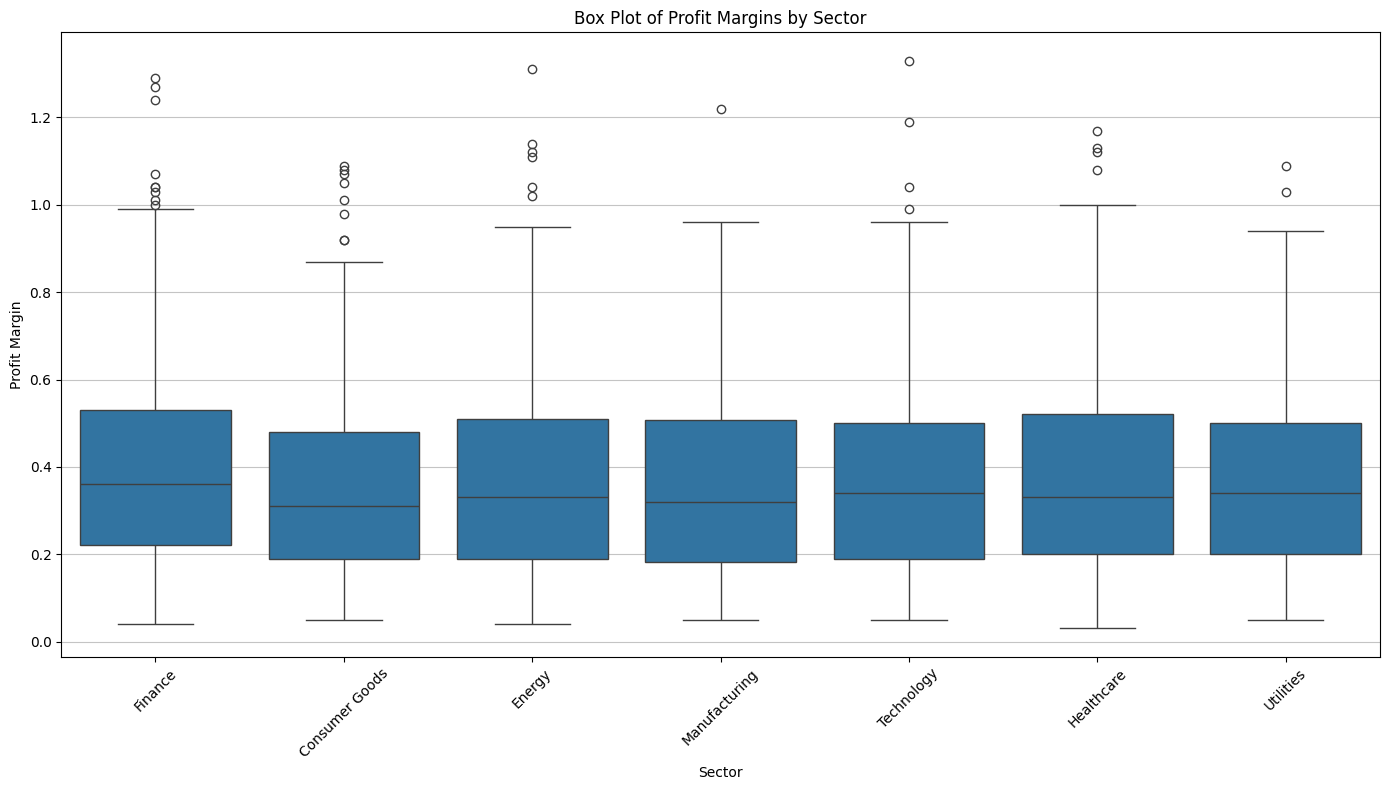

In [ ]:
# Box plot by company and sector
plt.figure(figsize=(14, 8))
sns.boxplot(x='sector', y='profit_margin', data=finance_df)
plt.title('Box Plot of Profit Margins by Sector')
plt.xlabel('Sector')
plt.ylabel('Profit Margin')
plt.grid(axis='y', alpha=0.75)
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.tight_layout()  # Adjust layout to make room for rotated labels
plt.savefig('profit_margin_boxplot.png')
plt.show()

plt.figure(figsize=(14, 8)) creates a blank chart 14 inches by 8 inches, larger than the last one because seven sectors need the room.

sns.boxplot(x='sector', y='profit_margin', data=finance_df) is the first time seaborn gets used. data= selects the table being used, x= puts sector along the bottom of the chart, and y= puts profit margin along the left side. Seaborn splits the data by sector automatically.

plt.title, plt.xlabel, and plt.ylabel set the text. plt.grid(axis='y', alpha=0.75) adds faint horizontal lines. plt.xticks(rotation=45) turns the sector names 45 degrees so they don't overlap. plt.tight_layout() shifts the layout so those rotated labels don't get cut off. plt.savefig('profit_margin_boxplot.png') saves the chart as an image and plt.show() displays it.

Each sector gets one box. The box covers the middle half of the values, running from the 25th percentile at the bottom to the 75th at the top. The line inside the box is the median. The thin lines sticking out are whiskers, which reach the furthest values that still count as normal. The circles above them are outliers, values far enough from the rest to be plotted on their own. These are the same 25%, 50%, and 75% figures from .describe(), drawn instead of listed.

The output shows seven sectors and how similar they are. The medians all sit roughly between 0.31 and 0.36. Finance is the highest and Consumer Goods the lowest, with a small gap between them. The boxes are close to the same height as well, so the spread within each sector is comparable.

In [ ]:
# Identifying outliers in P/E ratio using Z-score
z_scores = np.abs((finance_df['pe_ratio'] - finance_df['pe_ratio'].mean()) / finance_df['pe_ratio'].std())
outliers = finance_df[z_scores > 3]

print("\nOutliers in P/E Ratio (Z-score > 3):")
print(outliers[['year', 'quarter', 'company_id', 'sector', 'pe_ratio', 'profit_margin']])


Outliers in P/E Ratio (Z-score > 3):
      year  quarter company_id          sector  pe_ratio  profit_margin
0     2000        1  Company_1         Finance      3.71           0.04
1     2000        1  Company_2  Consumer Goods      2.88           0.06
25    2000        2  Company_1      Healthcare      2.64           0.07
225   2002        2  Company_1      Technology      2.91           0.09
250   2002        3  Company_1      Healthcare      6.26           0.03
251   2002        3  Company_2          Energy      4.87           0.04
252   2002        3  Company_3      Technology      3.98           0.05
253   2002        3  Company_4      Technology      3.37           0.06
254   2002        3  Company_5      Technology      2.92           0.07
350   2003        3  Company_1         Finance      2.79           0.09
425   2004        2  Company_1         Finance      2.64           0.06
575   2005        4  Company_1         Finance      3.31           0.05
650   2006        3  Compa

A z-score answers how unusual a value is. You take a value, subtract the average, and divide by the standard deviation. The result is how many standard deviations that value sits from average. The cutoff of 3 is used because about 99.7% of values normally fall within 3 standard deviations, so anything past that is among the most extreme.

finance_df['pe_ratio'] - finance_df['pe_ratio'].mean() subtracts the average P/E ratio from every value in the column. Positive means above average and negative means below. This happens to all 2,500 rows at once with no loop needed, thanks to numpy.

/ finance_df['pe_ratio'].std() divides by the standard deviation, converting the raw distances into standard-deviation units. np.abs(...) is absolute value, taking the negative sign off. Without it only unusually high numbers would get caught. With it, the unusually low ones count too. z_scores = ... stores one z-score per row.

outliers = finance_df[z_scores > 3] is filtering. z_scores > 3 creates True or False for each row, and putting that in square brackets keeps only the True rows. The print("\nOutliers in P/E Ratio (Z-score > 3):") line prints a label with a blank line before it. outliers[['year', 'quarter', ...]] selects several columns at once because of the double brackets, which trims the printout to the useful columns instead of all 12.

The cutoff checks out in the output. The lowest P/E in the list is 2.64, which matches the math from .describe(): the mean of 0.741 plus three times the standard deviation of 0.632 gives about 2.64. The code did what was predicted. 57 rows got flagged out of 2,500, which is about 2.3%.

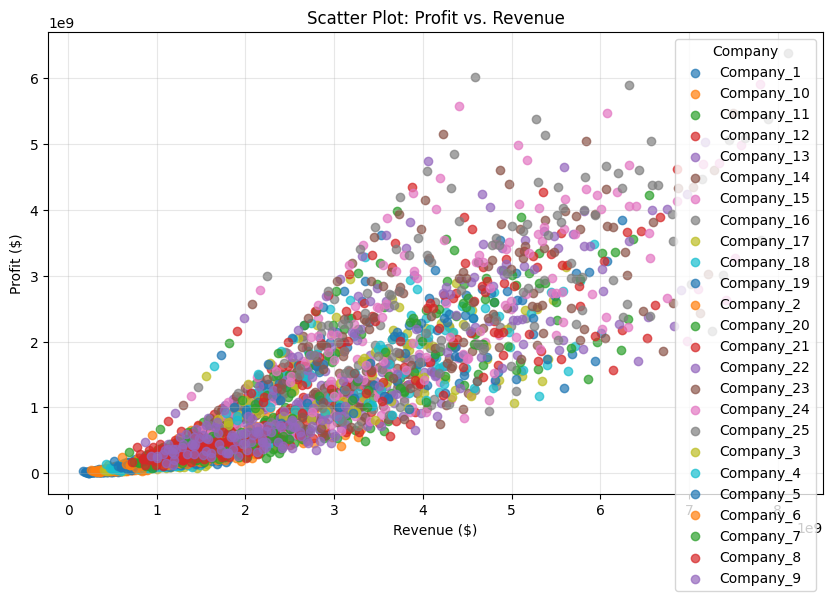

In [ ]:
# Scatter plot of profit vs. revenue
plt.figure(figsize=(10, 6))
for company, group in finance_df.groupby('company_id'):
    plt.scatter(group['revenue'], group['profit'], label=company, alpha=0.7)

plt.title('Scatter Plot: Profit vs. Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Profit ($)')
plt.legend(title='Company')
plt.grid(True, alpha=0.3)
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))  # Scientific notation for large numbers
plt.savefig('profit_revenue_scatter.png')
plt.show()

plt.figure(figsize=(10, 6)) creates a blank chart 10 inches by 6 inches.

finance_df.groupby('company_id') splits the table into separate chunks, one per company. for company, group in ...: is a loop that runs once for each chunk. company holds the name and group holds that company's rows. The indented line below runs 25 times, once per company.

plt.scatter(group['revenue'], group['profit'], label=company, alpha=0.7) plots the dots. Each dot is one row, placed by revenue across and profit up. label=company is what places the names in the legend. alpha=0.7 makes the dots slightly transparent so overlapping ones are visible. Because of the loop, each company gets plotted separately and matplotlib gives each one a different color.

plt.legend(title='Company') builds the legend box from those labels. plt.grid(True, alpha=0.3) creates a grid on both axes with slight transparency. scilimits with axis='both' puts scientific notation on both axes, which is the 1e9 in the two corners indicating the numbers are in billions. plt.savefig('profit_revenue_scatter.png') saves the chart as an image and plt.show() displays it.

The output shows that profit rises with revenue. The shape fans out to the right, meaning the higher the revenue, the wider the range of possible profit. The fan is arithmetic, since profit equals revenue times profit margin and the margins run from 0.03 to over 1.0.

One problem with this chart is the legend. It lists 25 companies and takes up a good portion of the space, but the colors repeat and are impossible to tell apart, so it does not actually help you read the chart.

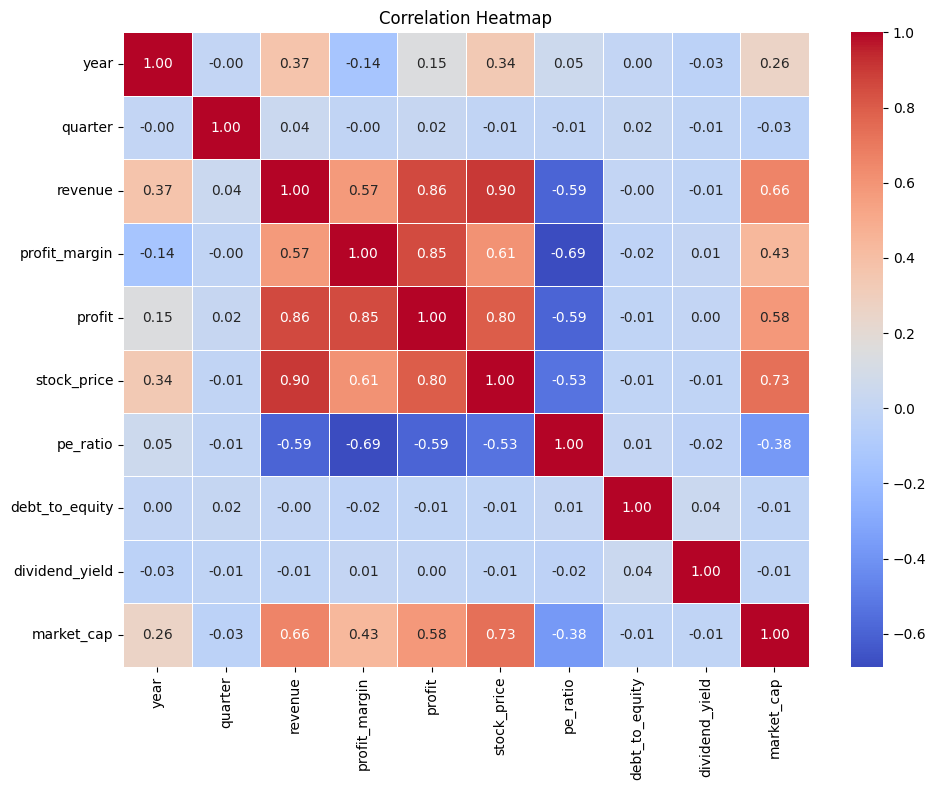

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation = finance_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()


plt.figure(figsize=(10, 8)) creates a blank chart 10 inches by 8 inches.

Correlation measures how two things move together, on a scale from -1 to 1. Closer to 1 means when one goes up the other goes up. Closer to -1 means when one goes up the other goes down. Close to 0 means no relationship.

finance_df.select_dtypes(include=[np.number]) only keeps the numeric columns, dropping company_id and sector, for the same reason .describe() skipped them. .corr() compares every numeric column against every other column and returns a grid of correlation values.

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5) draws that grid as colors. annot=True writes the numbers inside the squares. cmap='coolwarm' sets the color scheme, red for high and blue for low. fmt='.2f' rounds to two decimal places. linewidths=0.5 puts a thin line between squares. plt.title sets the heading, plt.tight_layout() adjusts spacing so nothing gets cut off, plt.savefig('correlation_heatmap.png') saves the image, and plt.show() displays it.

In the output, the diagonal is all 1.00 because every column correlates perfectly with itself. The grid is mirrored across that diagonal, so each pair appears twice. The strongest relationships are revenue and stock price at 0.90, revenue and profit at 0.86, and profit margin and profit at 0.85.

P/E ratio is negative against everything, strongest with profit margin at -0.69. That is the same pattern from the z-score cell, where every P/E outlier also had a low profit margin. This puts a number on it. Meanwhile debt_to_equity, dividend_yield, and quarter sit near zero against everything, meaning they do not move with any other column.

One thing to keep in mind is that correlation shows things moving together, not one causing the other.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
